# Mean-Variance Efficient Frontier

This notebook builds a mean-variance efficient frontier from historical ETF
prices. We use **James-Stein** shrinkage for expected returns and the
**Oracle Approximating Shrinkage (OAS)** estimator for the covariance matrix,
then extract the tangency and minimum-risk portfolios.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyvallocation import (
    PortfolioWrapper,
    estimate_moments,
)

## Load ETF price data

The bundled CSV contains daily prices for DBC, GLD, SPY, and TLT.

In [2]:
from pathlib import Path

_candidates = [
    Path("examples/ETF_prices.csv"),
    Path("../examples/ETF_prices.csv"),
    Path("../../examples/ETF_prices.csv"),
    Path("../../../examples/ETF_prices.csv"),
]
_csv = next((p for p in _candidates if p.exists()), None)
if _csv is None:
    raise FileNotFoundError("ETF_prices.csv not found")
prices = pd.read_csv(_csv, index_col="Date", parse_dates=True)
prices = prices.dropna(how="all").ffill()
returns = prices.pct_change().dropna(how="any")

print(f"Assets : {list(returns.columns)}")
print(f"Periods: {len(returns)}")
returns.tail()

Assets : ['DBC', 'GLD', 'SPY', 'TLT']
Periods: 4855


,DBC,GLD,SPY,TLT
Date,,,,
2025-05-19,-0.001416,0.012881,0.001094,-0.002897
2025-05-20,0.012760,0.018622,-0.003362,-0.007205
2025-05-21,-0.001400,0.007379,-0.016851,-0.017090
2025-05-22,-0.005140,-0.008861,0.000395,0.005240
2025-05-23,0.005636,0.021906,-0.006826,0.001659


## Estimate moments with shrinkage estimators

- **James-Stein** shrinks the sample mean toward a common grand mean.
- **OAS** (Oracle Approximating Shrinkage) regularises the covariance.

In [3]:
mu, cov = estimate_moments(
    returns,
    mean_estimator="james_stein",
    cov_estimator="oas",
)

print("Shrunk expected returns:")
print(mu.round(6))
print("\nShrunk covariance (diagonal):")
print(np.diag(cov).round(6))

Shrunk expected returns:
DBC    0.000139
GLD    0.000378
SPY    0.000417
TLT    0.000186
Name: mu, dtype: float64

Shrunk covariance (diagonal):
[1.48e-04 1.26e-04 1.53e-04 9.00e-05]


## Build the efficient frontier

In [4]:
wrapper = PortfolioWrapper.from_moments(mu, cov)
frontier = wrapper.variance_frontier(num_portfolios=20)

## Extract key portfolios

- **Minimum-risk**: lowest volatility on the frontier.
- **Tangency**: highest Sharpe ratio (assuming 1% risk-free rate).

In [5]:
min_w, min_ret, min_vol = frontier.min_risk()
tan_w, tan_ret, tan_vol = frontier.tangency(risk_free_rate=0.0001)

print("=== Minimum-Risk Portfolio ===")
print(min_w.round(4))
print(f"Return: {min_ret:.4%} | Volatility: {min_vol:.4%}\n")

print("=== Tangency Portfolio (rf=0.01%) ===")
print(tan_w.round(4))
print(f"Return: {tan_ret:.4%} | Volatility: {tan_vol:.4%}")

=== Minimum-Risk Portfolio ===
DBC    0.1543
GLD    0.1086
SPY    0.2562
TLT    0.4810
Name: Min Risk Portfolio, dtype: float64
Return: 0.0259% | Volatility: 0.5643%

=== Tangency Portfolio (rf=0.01%) ===
DBC    0.0001
GLD    0.3203
SPY    0.4085
TLT    0.2711
Name: Tangency Portfolio (rf=0.01%), dtype: float64
Return: 0.0342% | Volatility: 0.6484%


## Plot the efficient frontier

The frontier curve is annotated with the minimum-risk and tangency portfolios.

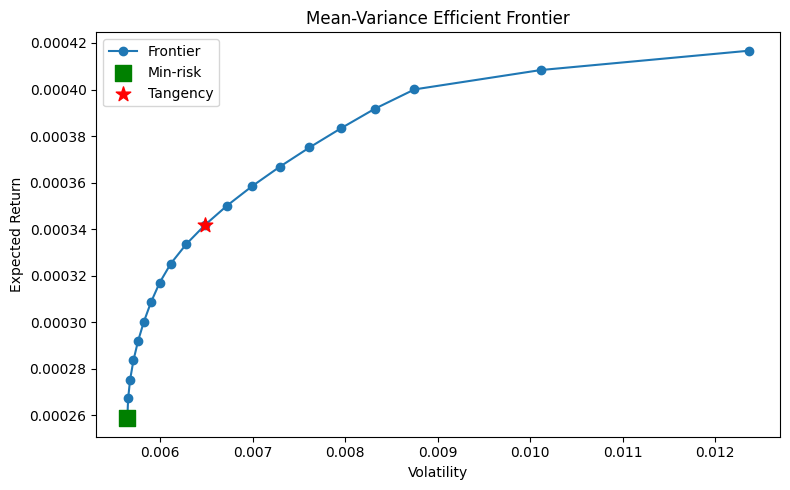

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(frontier.risks, frontier.returns, "o-", label="Frontier")
ax.scatter(min_vol, min_ret, s=120, marker="s",
           color="green", zorder=5, label="Min-risk")
ax.scatter(tan_vol, tan_ret, s=120, marker="*",
           color="red", zorder=5, label="Tangency")
ax.set_xlabel("Volatility")
ax.set_ylabel("Expected Return")
ax.set_title("Mean-Variance Efficient Frontier")
ax.legend()
fig.tight_layout()
plt.show()

## Portfolio weights comparison

In [7]:
comparison = pd.DataFrame({
    "Min-Risk": min_w,
    "Tangency": tan_w,
})
print(comparison.round(4))

     Min-Risk  Tangency
DBC    0.1543    0.0001
GLD    0.1086    0.3203
SPY    0.2562    0.4085
TLT    0.4810    0.2711
